In [1]:
# impolementging simple chat bot usign langgraph


In [2]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

e:\RAG AGENTIC AI\AGENTIC_AI_WITH_LANGGRAPH\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


python-dotenv could not parse statement starting at line 8


In [5]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
# llm.invoke("Hello")

In [6]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="<think>\nOkay, the user is Krish and enjoys playing cricket. I should acknowledge their interest and maybe ask some follow-up questions to engage them more. Let me see... What aspects of cricket do people usually talk about? Maybe their favorite teams, positions, or memorable matches? I could ask about what they like most about the game. Also, maybe if they play recreationally or follow professional leagues. I should make sure to keep the conversation friendly and open-ended to let them explore the topic further. Let me check if there are any common questions or discussions around cricket that would be relevant here. Perhaps mention some popular leagues like IPL or T20s, but only if they're from a cricket-playing country. Also, maybe ask if they prefer batting or bowling. Alright, time to put that together in a natural, conversational way without being too pushy.\n</think>\n\nHey Krish! 🏏 That's awesome—cricket is such a thrilling sport to play and watch. Whether it'

In [7]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

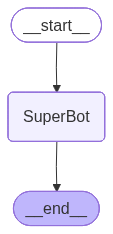

In [8]:

graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='bd901c61-a786-49b8-a01b-d23d91447c20'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Krish and mentioned he likes cricket. I should acknowledge his name and express interest in cricket. I can ask follow-up questions to learn more about what aspects of cricket he enjoys, his favorite teams or players, or if he plays the game. This helps build a more engaging conversation and shows genuine interest in his hobby. I should keep the tone friendly and open-ended to encourage further interaction.\n</think>\n\nHi Krish! Nice to meet you! 🏏 I love that you're into cricket—it's such an exciting sport. Do you follow any particular teams or players? Also, do you play yourself, or are you more of a passionate spectator? Let me know what part of the game you enjoy the most! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 

In [11]:
# ### Streaming 
# Methods: .stream() and astream()

# - These methods are sync and async methods for streaming back results.

# Additional parameters in streaming modes for graph state

# - **values** : This streams the full state of the graph after each node is called.
# - **updates** : This streams updates to the state of the graph after each node is called.

# ![image.png](attachment:image.png)

In [13]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Harshit And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, let's see. The user is Harshit and he likes cricket. The previous conversation was with Krish, who also mentioned liking cricket. The assistant's response to Krish was friendly, asked about favorite teams, players, and whether he prefers watching or playing.\n\nNow, Harshit comes in with the same intro. I need to respond appropriately. Since the assistant's previous reply was structured around asking about favorite teams, players, and playing vs watching, I should follow a similar pattern but make sure it's personalized for Harshit. Maybe start with a greeting, mention the shared interest in cricket, and ask the same questions. Need to keep it friendly and engaging. Also, check if there's any need to reference Krish's conversation, but probably not necessary unless the user wants to connect. Just focus on Harshit here. Let me make sure the tone is consistent and welcoming. Alright, draft a response that's warm and invites Har

In [14]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1277aed2-23e8-4d2a-b389-ad80fd5a4a4a'), AIMessage(content="<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. I should acknowledge their name and interest first. Let's see, how can I respond appropriately? I should make sure to welcome them and show enthusiasm for their interest in cricket. Maybe ask them about their favorite teams or players to keep the conversation going. Also, I should keep the tone friendly and open for further interaction. Let me check if there's anything else in the history, but since this is the first message, just a basic response should be fine. Avoid using any technical jargon and keep it conversational. Alright, time to put it all together.\n</think>\n\nHello Krish! Welcome! 🏏 It's great to meet someone who loves cricket—I'd love to hear more about it! Do you have a favorite team or player? Also, ar

In [15]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, Harshit mentioned again that he likes football. Let me check the history. The first time he said he likes cricket, and the assistant asked about favorite teams and players. Then Harshit added he also likes football, and the assistant asked for more details. Now he said "I also like football" again. Maybe he wants to expand on that.\n\nI need to make sure I\'m not repeating the same questions. The user might be emphasizing their interest in football. Maybe they want to talk about it more. Let me think about different angles. The assistant has already asked about favorite teams, leagues, and whether they play or watch. Maybe ask about a specific aspect they enjoy in football, like the strategy, the players, or the culture. Also, maybe compare it with cricket if they like both.\n\nAlternatively, they might want to share some favorite moments or why they enjoy football. The assistant should keep the conversation open for them to 

In [16]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1277aed2-23e8-4d2a-b389-ad80fd5a4a4a'), AIMessage(content="<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. I should acknowledge their name and interest first. Let's see, how can I respond appropriately? I should make sure to welcome them and show enthusiasm for their interest in cricket. Maybe ask them about their favorite teams or players to keep the conversation going. Also, I should keep the tone friendly and open for further interaction. Let me check if there's anything else in the history, but since this is the first message, just a basic response should be fine. Avoid using any technical jargon and keep it conversational. Alright, time to put it all together.\n</think>\n\nHello Krish! Welcome! 🏏 It's great to meet someone who loves cricket—I'd love to hear more about it! Do you have a favorite team or player? Also, ar

In [17]:
# #### Streaming The Responses With astream Method

# **Streaming tokens**
# We often want to stream more than graph state.

# In particular, with chat model calls it is common to stream the **tokens** as they are generated.

# We can do this using the .astream_events method, which streams back events as they happen inside nodes!

# Each event is a dict with a few keys:

# - event: This is the type of event that is being emitted.
# - name: This is the name of event.
# - data: This is the data associated with the event.
# - metadata: Containslanggraph_node, the node emitting the event.

In [18]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e354d-e62f-7153-a4d9-11daf95fd41d', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1277aed2-23e8-4d2a-b389-ad80fd5a4a4a'), AIMessage(content="<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. I should acknowledge their name and interest first. Let's see, how can I respond appropriately? I should make sure to welcome them and show enthusiasm for their interest in cricket. Maybe ask them about their favorite teams or players to keep the conversation going. Also, I should keep the tone friendly and open for further interaction. Let me check if there's anything else in the history, but since th